🚀 MODEL TEST

📦 Model yükleniyor: best.pt

✅ Model yüklendi!
   • Sınıf sayısı: 264
   • Model tipi: <bound method Module.type of YOLO(
  (model): DetectionModel(
    (model): Sequential(
      (0): Conv(
        (conv): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(16, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (1): Conv(
        (conv): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), bias=False)
        (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
        (act): SiLU(inplace=True)
      )
      (2): C2f(
        (cv1): Conv(
          (conv): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1), bias=False)
          (bn): BatchNorm2d(32, eps=0.001, momentum=0.03, affine=True, track_running_stats=True)
          (act): SiLU(inplace=True)
        )
        (cv2): Conv(
          (conv): Conv2d(48, 32, ker

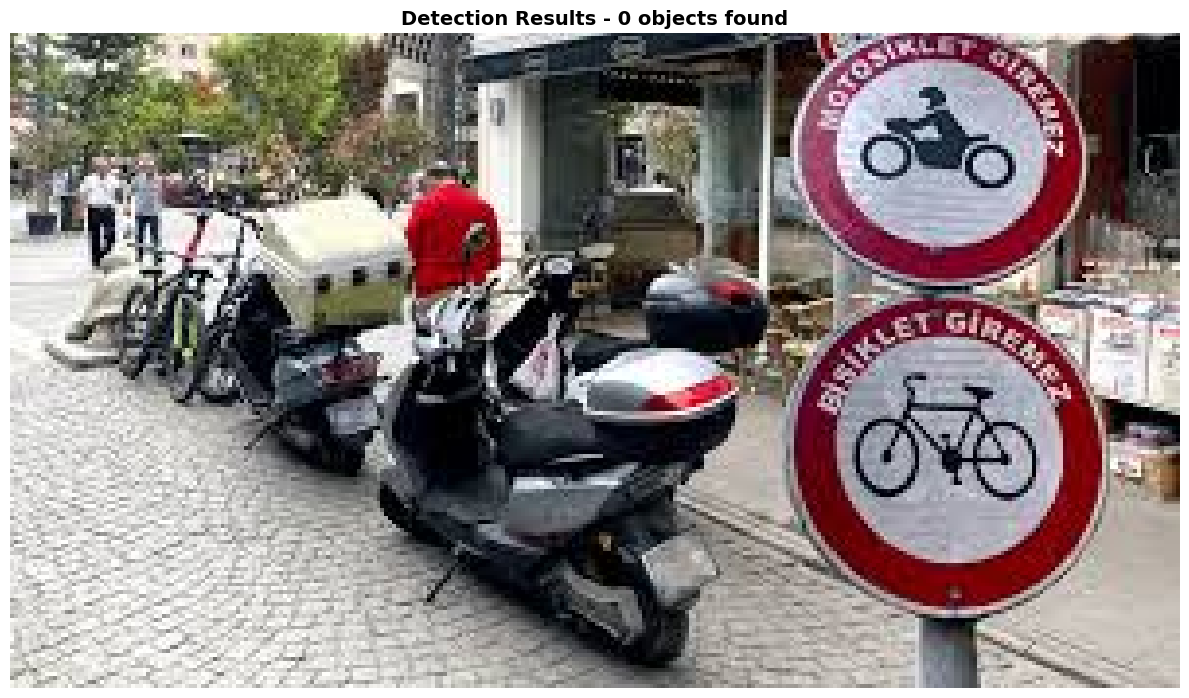


💾 Sonuç kaydedildi: prediction.jpg



In [5]:
from ultralytics import YOLO
from pathlib import Path
import cv2
import matplotlib.pyplot as plt

print("="*70)
print("🚀 MODEL TEST")
print("="*70)

# Modeli yükle
model_path = "best.pt"
print(f"\n📦 Model yükleniyor: {model_path}")
model = YOLO(model_path)

# Model bilgilerini göster
print(f"\n✅ Model yüklendi!")
print(f"   • Sınıf sayısı: {len(model.names)}")
print(f"   • Model tipi: {model.type}")

# Test görseli
test_image = "test_image.jpg"

# Görsel var mı kontrol et
if not Path(test_image).exists():
    print(f"\n❌ HATA: {test_image} bulunamadı!")
    print(f"   Lütfen test görseli ekleyin veya yolu güncelleyin")
else:
    print(f"\n🖼️  Test görseli: {test_image}")
    
    # Tahmin yap
    print(f"\n🔍 Tahmin yapılıyor (confidence: 0.25)...")
    results = model.predict(test_image, conf=0.25, save=True, show_labels=True, show_conf=True)
    
    # Sonuçları analiz et
    result = results[0]
    boxes = result.boxes
    
    print(f"\n📊 Sonuçlar:")
    print(f"   • Tespit edilen nesne: {len(boxes)}")
    
    if len(boxes) > 0:
        print(f"\n🎯 Tespit edilen sınıflar:")
        for box in boxes:
            cls_id = int(box.cls[0])
            conf = float(box.conf[0])
            cls_name = model.names[cls_id]
            print(f"   • {cls_name}: {conf:.2%}")
    else:
        print(f"   ⚠️  Hiçbir nesne tespit edilemedi!")
        print(f"   💡 Confidence threshold'u düşürmeyi deneyin (conf=0.15)")
    
    # Görseli göster
    print(f"\n🖼️  Sonuç görseli gösteriliyor...")
    img_with_boxes = result.plot()
    
    plt.figure(figsize=(12, 8))
    plt.imshow(cv2.cvtColor(img_with_boxes, cv2.COLOR_BGR2RGB))
    plt.axis('off')
    plt.title(f'Detection Results - {len(boxes)} objects found', 
              fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    # Kaydet
    result.save("prediction.jpg")
    print(f"\n💾 Sonuç kaydedildi: prediction.jpg")

print("\n" + "="*70)